# Assignment 01: Jacobian Lens End-to-End

This notebook incorporates all steps from the original `walkthrough.ipynb` using `Qwen3.5-2B`, followed by the custom data extraction task (Part 3).

In [1]:
import jlens
import torch
import transformers
import json
import gzip
from pathlib import Path
from functools import partial
import threading
from http.server import HTTPServer, SimpleHTTPRequestHandler
import pandas as pd
from tqdm.auto import tqdm
from jlens.examples import EXAMPLES, resolve_prompt
from jlens.vis import build_page, compute_slice, notebook_iframe

jlens.configure_logging()

MODEL_NAME = "Qwen/Qwen3.5-2B"
LENS_REPO = "neuronpedia/jacobian-lens"
LENS_FILE = "qwen3.5-2b-pt/jlens/Salesforce-wikitext/Qwen3.5-2B-Base_jacobian_lens.pt"


## 1. Load the model

In [2]:
hf_model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.bfloat16, device_map="cuda", trust_remote_code=True
)
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = jlens.from_hf(hf_model, tokenizer, compile=False)
model


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/64.5k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…): reconstructing file:   0%|          |  0.00B / 4.55GB            

model.safetensors-00001-of-00001.safeten(…): downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

HFLensModel(Qwen3_5ForCausalLM, n_layers=24, d_model=2048)

## 2. Load a pre-fitted lens

In [4]:
lens = jlens.JacobianLens.from_pretrained(
    LENS_REPO, filename=LENS_FILE
)
lens


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

JacobianLens(d_model=2048, n_prompts=335, source_layers=[0..22] (23 layers))

## 3. Apply: J-lens vs logit lens
(From walkthrough)

In [5]:
prompt = "Fact: The currency used in the country shaped like a boot is"
layers = [
    model.n_layers // 4,
    model.n_layers // 2,
    model.n_layers // 4 * 3,
    model.n_layers - 2,
]

jlens_logits, model_logits, _ = lens.apply(model, prompt, layers=layers, positions=[-2])
logit_lens, _, _ = lens.apply(
    model, prompt, layers=layers, positions=[-2], use_jacobian=False
)

def top5(logits):
    return [tokenizer.decode([t]) for t in logits.topk(5).indices]

for layer in layers:
    print(f"L{layer:>3} logit-lens: {top5(logit_lens[layer][0])}")
    print(f"L{layer:>3} J-lens:     {top5(jlens_logits[layer][0])}")
print(f"model:           {top5(model_logits[0])}")


L  6 logit-lens: ['状', 'iah', '状的', 'atria', 'elp']
L  6 J-lens:     [' boots', '靴', ' boot', '-boot', 'boot']
L 12 logit-lens: ['less', ' weshalb', ' minder', 'let', '�']
L 12 J-lens:     [' boots', ' boot', '靴', 'boot', ' Boot']
L 18 logit-lens: ['iful', '答案是', '心地', '-shaped', '最常见']
L 18 J-lens:     ['靴', '-shaped', ' footwear', '/boot', ' boots']
L 22 logit-lens: [' is', ' was', ' consists', ' with', ' named']
L 22 J-lens:     [' is', ' was', ' consists', '-shaped', ',']
model:           [' is', ',', ' (', '.', ' was']


## 4. Render a slice page (inline)

In [7]:
try:
    gloss = {int(k): v for k, v in json.load(gzip.open("assets/qwen_gloss.json.gz")).items()}
except:
    gloss = {}

example = next(e for e in EXAMPLES if e.slug == "multihop")
prompt = resolve_prompt(example, tokenizer)

slice_data = compute_slice(
    model,
    lens,
    prompt,
    layer_stride=2,
    mask_display=True,
)
page, _, _ = build_page(
    slice_data,
    prompt,
    title=example.section,
    description=example.description,
    alt_token=gloss,
)
notebook_iframe(page)


## 5. Render a slice page (served)

In [ ]:
import os
xample = next(e for e in EXAMPLES if e.slug == "ascii-face")
prompt = resolve_prompt(example, tokenizer)

slice_data = compute_slice(model, lens, prompt, mask_display=True)
out_dir = Path("slices") / example.slug
out_dir.mkdir(parents=True, exist_ok=True)

page, _, _ = build_page(
    slice_data,
    prompt,
    title=example.section,
    description=example.description,
    alt_token=gloss,
    mode="fetch",
    out_dir=out_dir,
)
(out_dir / "index.html").write_text(page)

if "_jlens_httpd" not in globals():
    _handler = partial(SimpleHTTPRequestHandler, directory=os.path.abspath("slices"))
    _jlens_httpd = HTTPServer(("127.0.0.1", 0), _handler)
    threading.Thread(target=_jlens_httpd.serve_forever, daemon=True).start()
print(f"-> http://localhost:{_jlens_httpd.server_address[1]}/{example.slug}/")


-> http://localhost:46431/ascii-face/


127.0.0.1 - - [02/Sep/2026 11:07:17] "GET /ascii-face/ HTTP/1.1" 200 -
127.0.0.1 - - [02/Sep/2026 11:07:18] "GET /ascii-face/meta.json HTTP/1.1" 200 -
127.0.0.1 - - [02/Sep/2026 11:07:18] "GET /ascii-face/slice.bin HTTP/1.1" 200 -
127.0.0.1 - - [02/Sep/2026 11:07:18] code 404, message File not found
127.0.0.1 - - [02/Sep/2026 11:07:18] "GET /favicon.ico HTTP/1.1" 404 -


## 6. Fitting (Optional for Assignment)

In [ ]:
# From walkthrough, commented out to save time if you only need the evaluation part.
# from jlens.examples import load_wikitext_prompts
# prompts = load_wikitext_prompts(n_prompts=10) # reduced for speed
# new_lens = jlens.fit(
#     model, prompts, dim_batch=32, max_seq_len=128, checkpoint_path="ckpt.pt"
# )
# new_lens.save("jacobian_lens_fitted.pt")
print("Skipped fitting to proceed to custom assignment tasks.")


--- 

## Assignment Part 3: Custom Data Extraction
3.1. Call lens.apply() over all positions. 
3.2. Use prompts from data/experiments/. 
3.3. Pull top-1 token and rank of final predicted token.
3.4. Produce per-layer summary table.

In [11]:
# Load our custom experiment prompts
with open("experiments/data/bbq_lens_eval.json", "r") as f:
    data = json.load(f)
    
# Use subset of prompts to keep computation fast
prompts = [item["prompt"] for item in data["items"]][:10]
results = []

for p_idx, prompt in enumerate(tqdm(prompts, desc="Evaluating prompts")):
    inputs = tokenizer(prompt, return_tensors="pt")
    seq_len = inputs.input_ids.shape[1]
    
    # 3.1 All valid source positions
    positions = list(range(seq_len))
    
    # Apply lens
    jlens_logits, model_logits, _ = lens.apply(model, prompt, positions=positions, use_jacobian=True)
    final_preds = model_logits.argmax(dim=-1)
    
    # 3.3 Extract Top-1 and rank
    for pos in positions:
        final_token_id = final_preds[pos].item()
        
        for layer in lens.source_layers:
            layer_logits = jlens_logits[layer][pos]
            
            top1_id = layer_logits.argmax().item()
            top1_token = tokenizer.decode([top1_id])
            
            sorted_indices = layer_logits.argsort(descending=True)
            rank = (sorted_indices == final_token_id).nonzero().item() + 1
            
            results.append({
                "prompt_idx": p_idx,
                "position": pos,
                "layer": layer,
                "top1_token": top1_token.strip(),
                "rank_of_final": rank
            })

df = pd.DataFrame(results)


Evaluating prompts:   0%|          | 0/3 [00:00<?, ?it/s]

### 3.4 Summary Table & Visualization

,layer,avg_rank_of_final,median_rank_of_final,top_1_hits
0,0,25719.6,2677.000000,0.0%
1,1,15484.4,2914.500000,0.0%
2,2,25415.6,1861.000000,0.0%
3,3,1982.8,1043.500000,0.0%
4,4,2700.0,996.000000,0.0%
5,5,2391.2,690.000000,0.0%
6,6,4412.8,878.000000,0.0%
7,7,3642.1,815.500000,0.0%
8,8,6268.3,904.000000,0.0%
9,9,4171.4,902.500000,0.0%


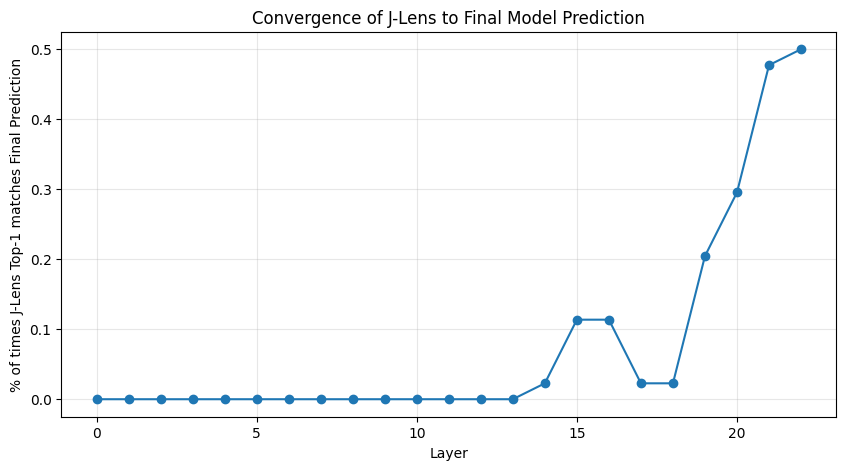

In [12]:
summary = df.groupby("layer").agg(
    avg_rank_of_final=("rank_of_final", "mean"),
    median_rank_of_final=("rank_of_final", "median"),
    top_1_hits=("rank_of_final", lambda x: (x == 1).mean())
).reset_index()

display(summary.style.background_gradient(cmap='viridis_r', subset=['avg_rank_of_final']).format({
    'avg_rank_of_final': '{:.1f}',
    'top_1_hits': '{:.1%}'
}))

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(summary['layer'], summary['top_1_hits'], marker='o')
plt.title("Convergence of J-Lens to Final Model Prediction")
plt.xlabel("Layer")
plt.ylabel("% of times J-Lens Top-1 matches Final Prediction")
plt.grid(True, alpha=0.3)
plt.show()
